<a href="https://colab.research.google.com/github/AbdulselamIsmail/Phishing-Attack-Lab/blob/main/PhishingEmailsModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Dataset


In [ ]:
pip install kagglehub

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
import os
import shutil

# Download the dataset to kagglehub's cache location
source_path = kagglehub.dataset_download("ethancratchley/email-phishing-dataset")

# Define the target path as requested by the user
target_path = "/kaggle/input/email-phishing-dataset"

# Create the target directory if it doesn't exist
os.makedirs(target_path, exist_ok=True)

# Check if the source path is already the target path
# This often happens if kagglehub directly extracts to the requested location or a cached one that's effectively the same
if os.path.abspath(source_path) == os.path.abspath(target_path):
    print(f"Dataset is already available at the target path: {target_path}")
else:
    # Move the contents (files and subdirectories) from the source_path to the target_path
    for item_name in os.listdir(source_path):
        source_item_path = os.path.join(source_path, item_name)
        target_item_path = os.path.join(target_path, item_name)

        if os.path.isdir(source_item_path):
            # If it's a directory, use copytree
            shutil.copytree(source_item_path, target_item_path, dirs_exist_ok=True)
        else:
            # If it's a file, use copy2
            shutil.copy2(source_item_path, target_item_path)

    print(f"Dataset contents moved from {source_path} to {target_path}")

Using Colab cache for faster access to the 'email-phishing-dataset' dataset.
Dataset is already available at the target path: /kaggle/input/email-phishing-dataset


In [ ]:
import os
import pandas as pd # Import pandas here

# The dataset is now in this directory as per the previous cell's operation
dataset_dir = "/kaggle/input/email-phishing-dataset"

# List the contents of the dataset directory to find the correct file name
print(os.listdir(dataset_dir))

# The correct file name is 'email_phishing_data.csv'
file_to_load = "email_phishing_data.csv"

# Load the data directly using pandas, as it's now in the specified local path
file_path = os.path.join(dataset_dir, file_to_load)
df = pd.read_csv(file_path)

print("First 5 records:", df.head())

['email_phishing_data.csv']
First 5 records:    num_words  num_unique_words  num_stopwords  num_links  num_unique_domains  \
0        140                94             52          0                   0   
1          5                 5              1          0                   0   
2         34                32             15          0                   0   
3          6                 6              2          0                   0   
4          9                 9              2          0                   0   

   num_email_addresses  num_spelling_errors  num_urgent_keywords  label  
0                    0                    0                    0      0  
1                    0                    0                    0      0  
2                    0                    0                    0      0  
3                    0                    0                    0      0  
4                    0                    0                    0      0  


# Dataset Adjustments

## Adjusting Data Imbalance

In [ ]:
import pandas as pd

# 1. Separate the classes
df_safe = df[df['label'] == 0]
df_phish = df[df['label'] == 1]

# 2. Find the count of the minority class (Phishing)
n_phish = len(df_phish)

# 3. Randomly sample from the majority class (Safe)
# to match the number of phishing emails
df_safe_downsampled = df_safe.sample(n=n_phish, random_state=42)

# 4. Combine them back together
df_balanced = pd.concat([df_safe_downsampled, df_phish])

# 5. Shuffle the new dataset (Important so the model doesn't learn 'chunks')
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 6. Verify the result
print("New Class Distribution:\n", df_balanced['label'].value_counts())

New Class Distribution:
 label
0    6949
1    6949
Name: count, dtype: int64


## Feaure extraction

In [ ]:
# Link Density Feature
df_balanced['link_density'] = df_balanced['num_links'] / (df_balanced['num_words'] + 1)

# Unique Word Density
df_balanced['unique_word_density'] = df_balanced['num_unique_words'] / (df_balanced['num_words'] + 1)

# New Feature: Stopwords Ratio
df_balanced['stopwords_ratio'] = df_balanced['num_stopwords'] / (df_balanced['num_words'] + 1)

# New Feature: Unique Domain Ratio (relative to number of links)
df_balanced['unique_domain_ratio'] = df_balanced['num_unique_domains'] / (df_balanced['num_links'] + 1)

# New Feature: Has Email Addresses (binary)
df_balanced['has_email_addresses'] = (df_balanced['num_email_addresses'] > 0).astype(int)

# New Feature: Spelling Error Ratio
df_balanced['spelling_error_ratio'] = df_balanced['num_spelling_errors'] / (df_balanced['num_words'] + 1)


## Data Normalization

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Identify feature columns (all columns except the label)
features = df_balanced.drop(columns=['label'])
target = df_balanced['label']

# 2. Initialize the Scaler
scaler = StandardScaler()

# 3. Fit and transform the feature data
features_scaled = scaler.fit_transform(features)

# 4. Convert back to a DataFrame for readability (optional but helpful)
df_features_scaled = pd.DataFrame(features_scaled, columns=features.columns)

print("Mean of scaled features (should be ~0):", df_features_scaled.mean().round(2).sum())
print("Std Dev of scaled features (should be 1):", df_features_scaled.std().round(2).mean())

Mean of scaled features (should be ~0): 0.0
Std Dev of scaled features (should be 1): 1.0


# Model Training

## Spliting Dataset


In [ ]:
from sklearn.model_selection import train_test_split

# Step 1: Split into Train (70%) and a temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    df_features_scaled, target, test_size=0.30, random_state=42, stratify=target
)

# Step 2: Split the temporary set (30%) into Test (15%) and Attack (15%)
# (Test size of 0.5 within the remaining 30% equals 15% of the total)
X_test, X_attack, y_test, y_attack = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Attack samples: {len(X_attack)}")

Training samples: 9728
Testing samples: 2085
Attack samples: 2085


## Random Forest Implementation

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the Model
# n_estimators=100 creates a forest of 100 decision trees
victim_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the Model using the training set
victim_model.fit(X_train, y_train)

# 3. Evaluate on the Test Set (The set it has never seen)
y_pred = victim_model.predict(X_test)

# 4. Print results
print(f"--- Victim Model Baseline Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- Victim Model Baseline Results ---
Accuracy: 0.7861

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.79      0.79      1042
           1       0.79      0.79      0.79      1043

    accuracy                           0.79      2085
   macro avg       0.79      0.79      0.79      2085
weighted avg       0.79      0.79      0.79      2085



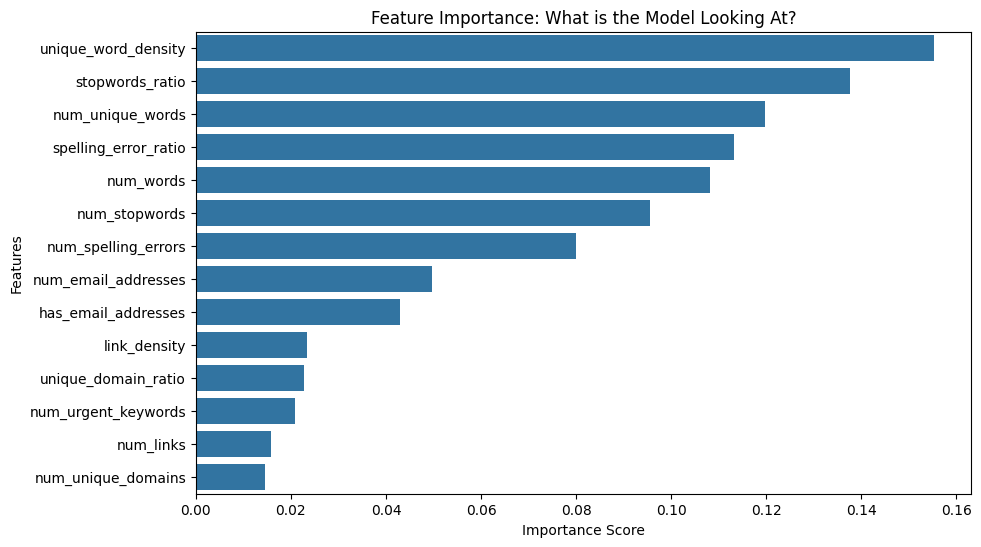

In [ ]:
# Create a series for feature importance
importances = pd.Series(victim_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Plot the features
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance: What is the Model Looking At?")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## SVM Implementation

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize the SVM Model
# Using a linear kernel for simplicity and often good baseline performance
svm_model = SVC(kernel='linear', random_state=42)

# 2. Train the Model using the training set
svm_model.fit(X_train, y_train)

# 3. Evaluate on the Test Set
y_pred_svm = svm_model.predict(X_test)

# 4. Print results
print(f"--- SVM Model Baseline Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


--- SVM Model Baseline Results ---
Accuracy: 0.6787

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.66      0.67      1042
           1       0.67      0.70      0.68      1043

    accuracy                           0.68      2085
   macro avg       0.68      0.68      0.68      2085
weighted avg       0.68      0.68      0.68      2085



## CatBoost Implementation

In [ ]:
import warnings
warnings.filterwarnings('ignore')

!pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize the CatBoost Model
# You can adjust parameters like iterations, learning_rate, depth, etc.
catboost_model = CatBoostClassifier(iterations=100,  # Number of boosting iterations
                                    learning_rate=0.1, # Step size shrinkage
                                    depth=6,         # Depth of the tree
                                    random_seed=42,  # For reproducibility
                                    verbose=0)       # Suppress verbose output

# 2. Train the Model using the training set
catboost_model.fit(X_train, y_train)

# 3. Evaluate on the Test Set
y_pred_catboost = catboost_model.predict(X_test)

# 4. Print results
print(f"--- CatBoost Model Baseline Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_catboost):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_catboost))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.6 MB/s eta 0:00:00
--- CatBoost Model Baseline Results ---
Accuracy: 0.7612

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.74      0.76      1042
           1       0.75      0.78      0.77      1043

    accuracy                           0.76      2085
   macro avg       0.76      0.76      0.76      2085
weighted avg       0.76      0.76      0.76      2085



## KNN implementation

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize the KNN Model
# You can choose the number of neighbors (n_neighbors) and the distance metric (e.g., 'minkowski' and p=2 for Euclidean)
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

# 2. Train the Model using the training set
knn_model.fit(X_train, y_train)

# 3. Evaluate on the Test Set
y_pred_knn = knn_model.predict(X_test)

# 4. Print results
print(f"--- KNN Model Baseline Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

--- KNN Model Baseline Results ---
Accuracy: 0.7568

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.75      0.76      1042
           1       0.76      0.76      0.76      1043

    accuracy                           0.76      2085
   macro avg       0.76      0.76      0.76      2085
weighted avg       0.76      0.76      0.76      2085



# Attacking

In [ ]:
# 1. Get predictions on the Attack set
attack_preds = victim_model.predict(X_attack)

# 2. Find indices where the model CORRECTLY identified Phishing (Label 1)
# These are our "targets" for the attack
target_indices = (y_attack == 1) & (attack_preds == 1)
X_targets = X_attack[target_indices]

print(f"Number of phishing emails ready to be attacked: {len(X_targets)}")

Number of phishing emails ready to be attacked: 809


## Changing Most Important Feature

In [ ]:
# 1. Create a copy of the phishing emails the model currently catches
X_adversarial_padding = X_targets.copy()

# 2. Attack: Set 'num_unique_words' to a very high value
# (Simulating an attacker adding many unique words to the email)
# We'll set it to the maximum value found in the training set
X_adversarial_padding['num_unique_words'] = X_train['num_unique_words'].max()

# 3. Check the "Flipped" labels
adv_preds_padding = victim_model.predict(X_adversarial_padding)
padding_success_rate = (adv_preds_padding == 0).mean()

print(f"Padding Attack Success Rate: {padding_success_rate * 100:.2f}%")

Padding Attack Success Rate: 0.99%


## Multi Variable Attack

### Extreme Case

In [ ]:
# 1. Create a fresh copy of your caught phishing targets
X_adv_combined = X_targets.copy()

# 2. Multi-feature attack:
# - Decrease unique words density (Padding)
# - Decrease urgent keywords (Tone softening)
# - Increase spelling errors

X_adv_combined['num_urgent_keywords'] = X_train['num_urgent_keywords'].min()
X_adv_combined['num_spelling_errors'] = X_train['num_spelling_errors'].max()
X_adv_combined['unique_word_density'] = X_train['unique_word_density'].min()


# 3. Check for flips
combined_preds = victim_model.predict(X_adv_combined)
combined_success = (combined_preds == 0).mean()

print(f"Combined Attack Success Rate: {combined_success * 100:.2f}%")

Combined Attack Success Rate: 69.47%


### Likely case

In [ ]:
# 1. Create a fresh copy
X_adv_v2 = X_targets.copy()

# 2. Targeted "Structural" Attack:
# Minimize the Red Flags
X_adv_v2['num_urgent_keywords'] = 0
X_adv_v2['num_spelling_errors'] = 0 # Professional attackers don't make typos

# Maximize the "Safe" Markers
# Set stopwords_ratio to the 90th percentile of 'Safe' emails
X_adv_v2['stopwords_ratio'] = X_train[y_train == 0]['stopwords_ratio'].quantile(0.9)

# Set unique_word_density to a "Natural" human average (0.5)
X_adv_v2['unique_word_density'] = 0.5

# Dilute the Link Density
# (Pretend we added 200 'Safe' words to the email body)
X_adv_v2['num_words'] = X_adv_v2['num_words'] + 200
X_adv_v2['link_density'] = X_adv_v2['num_links'] / (X_adv_v2['num_words'] + 1)

# 3. Check for flips
v2_preds = victim_model.predict(X_adv_v2)
v2_success = (v2_preds == 0).mean()

print(f"Stealth 2.0 Attack Success Rate: {v2_success * 100:.2f}%")

Stealth 2.0 Attack Success Rate: 9.39%


# Adversarial Training

In [ ]:
import numpy as np

# 1. Create a "Robust" Training Set
# We take the 69.47% that fooled the model and tell the model: "THESE ARE PHISHING"
X_failed_to_catch = X_adv_v2[combined_preds == 0]
y_failed_to_catch = pd.Series([1] * len(X_failed_to_catch))

# 2. Combine with original training data
X_train_robust = pd.concat([X_train, X_failed_to_catch])
y_train_robust = pd.concat([y_train, y_failed_to_catch])

# 3. Train the new "Defender" model
defender_model = RandomForestClassifier(n_estimators=100, random_state=42)
defender_model.fit(X_train_robust, y_train_robust)

# 4. Retest the "Max Words" attack on the new Defender
final_preds = defender_model.predict(X_adv_v2)
final_success_rate = (final_preds == 0).mean()

print(f"Initial Attack Success: 9.39%")
print(f"Post-Defense Attack Success: {final_success_rate * 100:.2f}%")

Initial Attack Success: 9.39%
Post-Defense Attack Success: 0.00%


In [ ]:
from sklearn.metrics import f1_score

y_pred_defender = defender_model.predict(X_test)
f1 = f1_score(y_test, y_pred_defender)

print(f"Defender Model F1 Score on Test Set: {f1:.4f}")

Defender Model F1 Score on Test Set: 0.7884


# Saving Models For Application

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
print("Columns in order:\n", df_balanced.columns.tolist())

Columns in order:
 ['num_words', 'num_unique_words', 'num_stopwords', 'num_links', 'num_unique_domains', 'num_email_addresses', 'num_spelling_errors', 'num_urgent_keywords', 'label', 'link_density', 'unique_word_density', 'stopwords_ratio', 'unique_domain_ratio', 'has_email_addresses', 'spelling_error_ratio']


In [ ]:
import joblib

# Save the models and the scaler for your future FastAPI app
joblib.dump(victim_model, 'victim_model.joblib')
joblib.dump(defender_model, 'defender_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

print("Models and Scaler saved!")

Models and Scaler saved!
